# N-gram TF-IDF EDA of Hearing Utterances

Exploratory analysis of **2-, 3-, and 4-gram TF-IDF** representations of the `text` column in `utterances_sample_labeled.csv`.

**Outline**
1. Load & basic profiling
2. Build TF-IDF matrices (per-n and combined 2–4)
3. Dimensionality reduction (TruncatedSVD → t-SNE) and k-means cluster analysis
4. Cluster visualizations, colored by cluster / `speaker.position` / `section`
5. Top-10 n-grams most correlated with each `speaker.position` and `section` class (one-vs-rest)

In [1]:
import warnings, re
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import sparse

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import normalize

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_colwidth", 80)
RANDOM_STATE = 42

DATA_PATH = "utterances_sample_labeled.csv"   # adjust if needed

## 1. Load and profile the data

In [2]:
df = pd.read_csv(DATA_PATH)
print("Raw shape:", df.shape)
df = df.dropna(subset=["text"]).copy()
df["text"] = df["text"].astype(str)
df["n_words"] = df["text"].str.split().str.len()
print("After dropping empty text:", df.shape)
df.head(3)

Raw shape: (2619, 8)
After dropping empty text: (2618, 9)


,state,bid,hid,uid,pid,speaker.position,section,text,n_words
0,CA,CA_201520160AB2050,255341,0,55,PRESIDING_CHAIR,INTRO,ORG woman BILL_AUTHOR you have three matters if it's all right with you BILL...,80
1,CA,CA_201520160AB2050,255341,1,101330,BILL_AUTHOR,PRESENTATION,good morning mr chair and members thank you for the opportunity to present B...,369
2,CA,CA_201520160AB2050,255341,2,55,PRESIDING_CHAIR,PRESENTATION,that is correct what they've been doing we've got a variety of bills to try ...,24


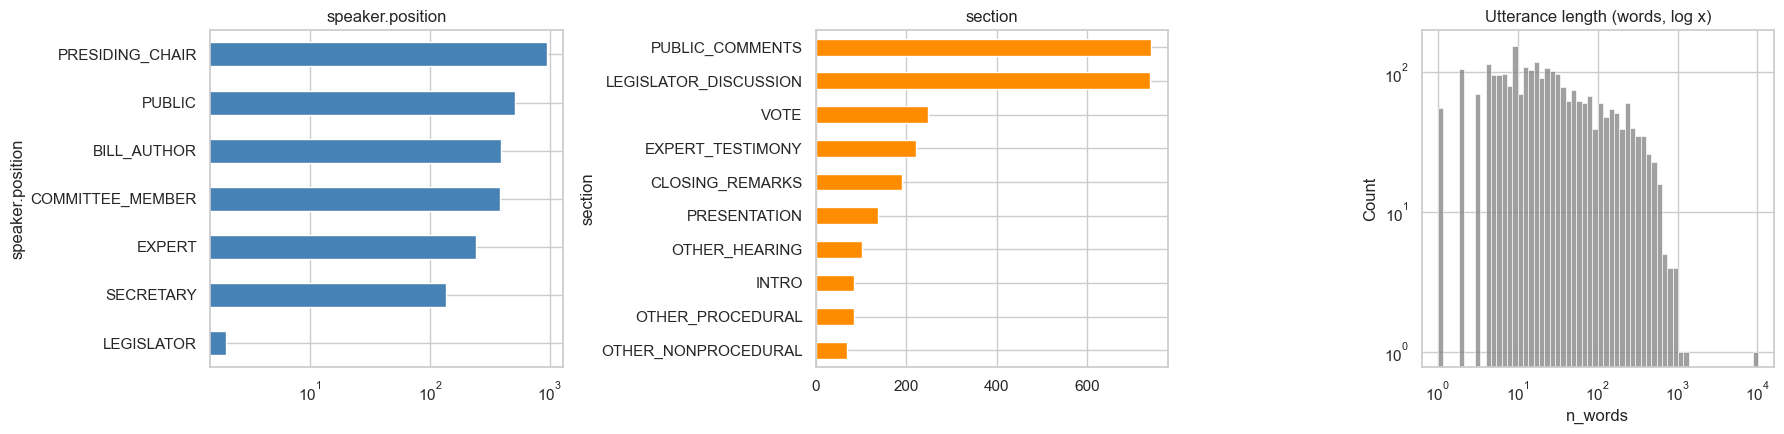

,count,mean,std,min,25%,50%,75%,max
n_words,2618.0,72.124523,231.042878,1.0,8.0,20.0,66.0,10154.0


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))
df["speaker.position"].value_counts().plot.barh(ax=axes[0], color="steelblue")
axes[0].set_title("speaker.position")
axes[0].set_xscale('log')
axes[0].invert_yaxis()
df["section"].value_counts().plot.barh(ax=axes[1], color="darkorange")
axes[1].set_title("section")
axes[1].invert_yaxis()
sns.histplot(df["n_words"], bins=60, log_scale=True, ax=axes[2], color="gray")
axes[2].set_title("Utterance length (words, log x)")
axes[2].set_yscale('log')
plt.tight_layout()
plt.show()

df["n_words"].describe().to_frame("n_words").T

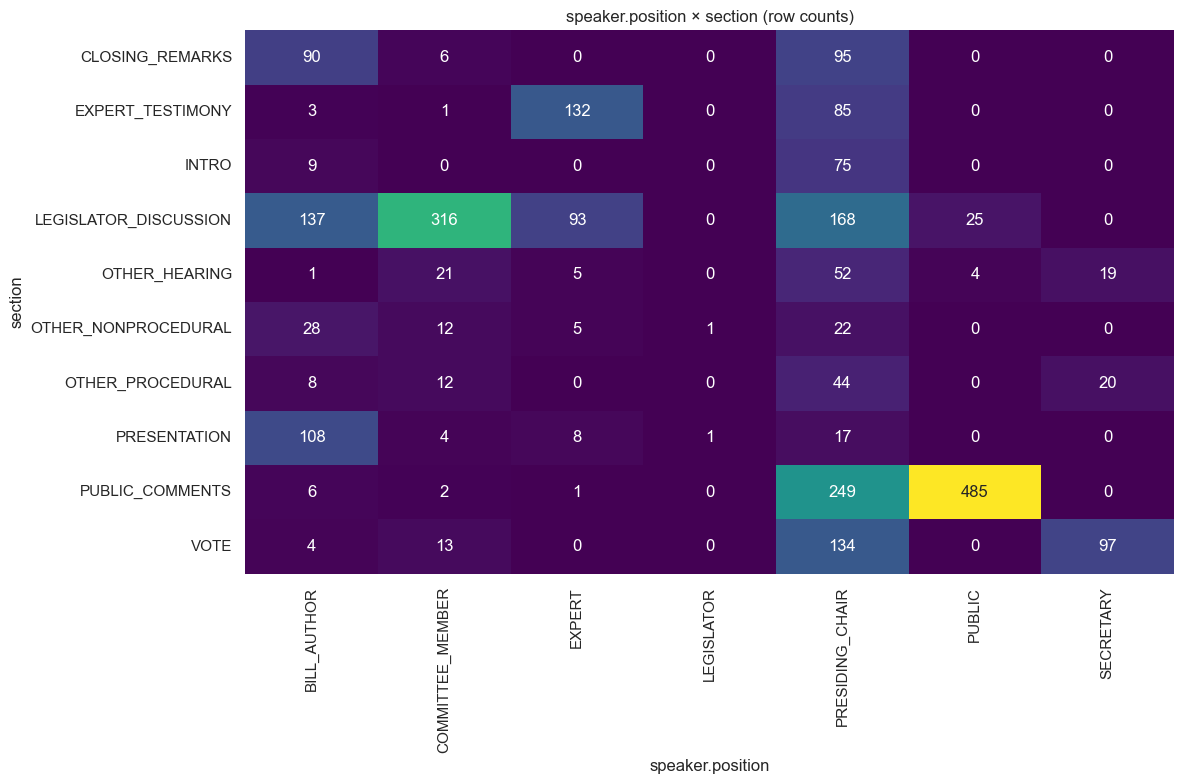

In [4]:
# Cross-tab of the two label columns — useful context for interpreting clusters later
ct = pd.crosstab(df["section"], df["speaker.position"])
plt.figure(figsize=(12, 8))
sns.heatmap(ct, annot=True, fmt="d", cmap="viridis", cbar=False)
plt.title("speaker.position × section (row counts)")
plt.tight_layout(); plt.show()

## 2. TF-IDF n-gram features

Notes on preprocessing:
- The text is already lower-cased and has entity placeholders (`ORG`, `BILL`, `BILL_AUTHOR`, `AB2050`, …). We keep these as tokens — they are informative for role/section.
- Token pattern keeps alphanumerics and underscores (so `BILL_AUTHOR` stays one token) and allows 1-char tokens like `i`.
- `min_df=3` drops n-grams that appear in fewer than 3 utterances; `sublinear_tf=True` dampens the very long presentation utterances.
- Utterances are extremely skewed in length (median ≈ 20 words, max > 10k), so L2 row-normalisation (the default) matters.

In [5]:
TOKEN_PATTERN = r"(?u)\b\w+\b"

def make_vectorizer(ngram_range, min_df=3):
    return TfidfVectorizer(
        ngram_range=ngram_range,
        token_pattern=TOKEN_PATTERN,
        lowercase=False,          # already lower-cased except placeholders; keep case
        min_df=min_df,
        max_df=0.95,
        sublinear_tf=True,
        norm="l2",
        dtype=np.float32,
    )

texts = df["text"].tolist()

# Per-n matrices for comparison + combined 2–4 matrix used for clustering & correlations
tfidf = {}
for n in (2, 3, 4):
    vec = make_vectorizer((n, n))
    X = vec.fit_transform(texts)
    tfidf[n] = (vec, X)
    print(f"{n}-grams: {X.shape[1]:>7,} features | nnz/doc = {X.nnz/X.shape[0]:.1f} | "
          f"docs with no feature = {(X.getnnz(axis=1)==0).sum()}")

vec_all = make_vectorizer((2, 4))
X_all = vec_all.fit_transform(texts)
feat_all = np.array(vec_all.get_feature_names_out())
print(f"\ncombined 2–4-grams: {X_all.shape[1]:,} features")

2-grams:   9,890 features | nnz/doc = 36.8 | docs with no feature = 83
3-grams:   5,858 features | nnz/doc = 14.6 | docs with no feature = 323
4-grams:   2,216 features | nnz/doc = 4.9 | docs with no feature = 698

combined 2–4-grams: 17,964 features


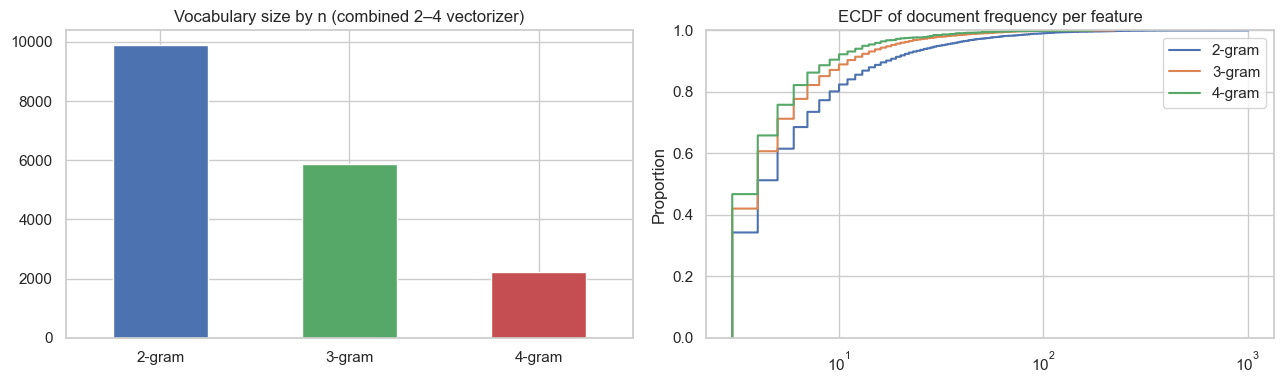

,n_features
2-gram,9890
3-gram,5858
4-gram,2216


In [6]:
# Vocabulary composition of the combined matrix and sparsity per n
ngram_len = np.array([len(f.split()) for f in feat_all])
comp = pd.Series(ngram_len).value_counts().sort_index().rename("n_features")
comp.index = [f"{i}-gram" for i in comp.index]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
comp.plot.bar(ax=axes[0], color=["#4c72b0", "#55a868", "#c44e52"], rot=0)
axes[0].set_title("Vocabulary size by n (combined 2–4 vectorizer)")

# document frequency distributions
for n, (vec, X) in tfidf.items():
    dfreq = np.asarray((X > 0).sum(axis=0)).ravel()
    sns.ecdfplot(dfreq, ax=axes[1], label=f"{n}-gram", log_scale=True)
axes[1].set_title("ECDF of document frequency per feature"); axes[1].legend()
plt.tight_layout(); plt.show()
comp.to_frame()

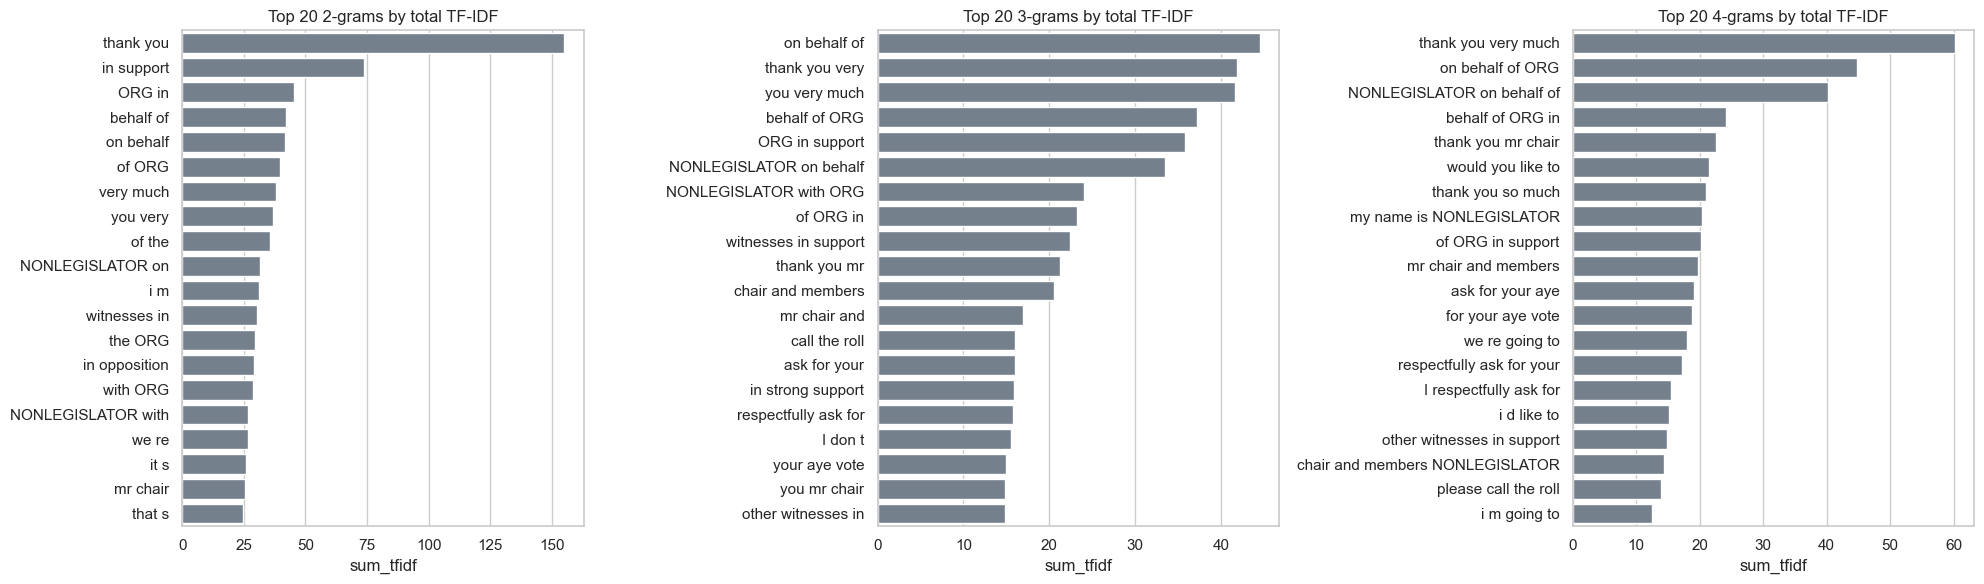

In [7]:
# Top n-grams by summed TF-IDF weight for each n
def top_features(vec, X, k=20):
    s = np.asarray(X.sum(axis=0)).ravel()
    idx = np.argsort(-s)[:k]
    return pd.DataFrame({"ngram": vec.get_feature_names_out()[idx], "sum_tfidf": s[idx]})

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
for ax, n in zip(axes, (2, 3, 4)):
    t = top_features(*tfidf[n], k=20)
    sns.barplot(data=t, y="ngram", x="sum_tfidf", ax=ax, color="slategray")
    ax.set_title(f"Top 20 {n}-grams by total TF-IDF"); ax.set_ylabel("")
plt.tight_layout(); plt.show()

## 2b. Filtering redundant n-grams by containment

Many bigrams are just fragments of a fixed phrase (`call the` almost always occurs inside `call the roll`), so keeping both the bigram and the trigram double-counts the same signal. We drop an n-gram *g* when

```max{g subset of h | |h| = n+1} for count(h)/count(g) >= CONTAIN_THRESHOLD```

i.e. when a single (n+1)-gram accounts for at least the threshold share of *g*'s occurrences (raw corpus counts, computed on the full vocabulary so rare extensions are not missed). Bigrams are checked against trigrams and trigrams against 4-grams; 4-grams are always kept. Taking the **max** over containing phrases (rather than the sum) is deliberate — nearly every bigram extends to *some* longer phrase, so the sum would flag almost everything.

In [8]:
CONTAIN_THRESHOLD = 0.8

# Raw counts over the *full* 2–4-gram vocabulary (min_df=1) so containment ratios are exact
from sklearn.feature_extraction.text import CountVectorizer
cv = CountVectorizer(ngram_range=(2, 4), token_pattern=TOKEN_PATTERN, lowercase=False, dtype=np.int32)
C = cv.fit_transform(texts)
cnt = pd.Series(np.asarray(C.sum(axis=0)).ravel(), index=cv.get_feature_names_out())
cnt_len = cnt.index.str.count(" ") + 1

def containment_ratio(counts, lengths, n):
    """For each n-gram: max over (n+1)-grams containing it of count(n+1-gram)/count(n-gram)."""
    sub = counts[lengths == n]
    sup = counts[lengths == n + 1]
    best = pd.Series(0, index=sub.index, dtype=np.int64)
    toks = sup.index.str.split(" ")
    prefix = toks.str[:-1].str.join(" ")
    suffix = toks.str[1:].str.join(" ")
    for parent in (prefix, suffix):
        m = pd.Series(sup.values, index=parent).groupby(level=0).max()
        m = m.reindex(best.index).fillna(0).astype(np.int64)
        best = np.maximum(best, m)
    return best / sub

ratio = pd.concat([containment_ratio(cnt, cnt_len, 2), containment_ratio(cnt, cnt_len, 3)])
ratio_tfidf = ratio.reindex(feat_all).fillna(0.0)          # 4-grams -> 0 (never dropped)
keep_mask = (ratio_tfidf < CONTAIN_THRESHOLD).values

summary = pd.DataFrame({
    "order": [f"{n}-gram" for n in ngram_len],
    "kept": keep_mask,
}).groupby("order")["kept"].agg(total="size", kept="sum")
summary["dropped"] = summary["total"] - summary["kept"]
summary["dropped_pct"] = (100 * summary["dropped"] / summary["total"]).round(1)
print(f"Threshold = {CONTAIN_THRESHOLD}: keeping {keep_mask.sum():,} of {len(feat_all):,} features")
summary

Threshold = 0.8: keeping 15,194 of 17,964 features


,total,kept,dropped,dropped_pct
order,,,,
2-gram,9890,8427,1463,14.8
3-gram,5858,4551,1307,22.3
4-gram,2216,2216,0,0.0


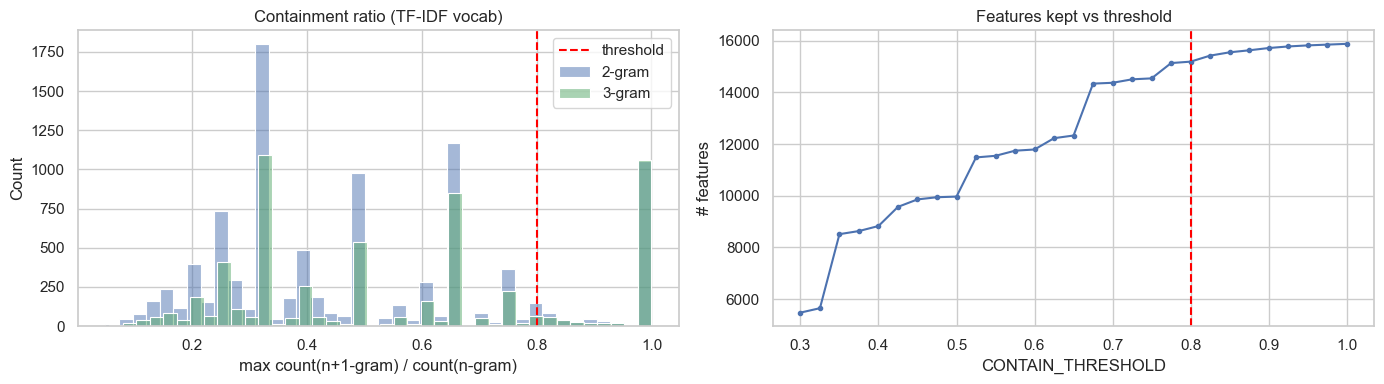

,ratio,count,absorbed_by
please call,1.0,50,please call the
pass with amendments,1.0,29,do pass with amendments
so thank,1.0,22,so thank you
right thank,1.0,21,right thank you
m sorry,1.0,23,i m sorry
members NONLEGISLATOR on,1.0,27,members NONLEGISLATOR on behalf
look forward,1.0,27,look forward to
m NONLEGISLATOR,1.0,22,i m NONLEGISLATOR
m a,1.0,47,i m a
m just,1.0,20,i m just


In [9]:
# Distribution of containment ratios, and examples of what gets dropped / kept
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for n, color in ((2, "#4c72b0"), (3, "#55a868")):
    sns.histplot(ratio_tfidf[ngram_len == n], bins=40, ax=axes[0], color=color, alpha=0.5, label=f"{n}-gram")
axes[0].axvline(CONTAIN_THRESHOLD, c="red", ls="--", label="threshold"); axes[0].legend()
axes[0].set_title("Containment ratio (TF-IDF vocab)"); axes[0].set_xlabel("max count(n+1-gram) / count(n-gram)")

# how many features survive as a function of threshold
grid = np.linspace(0.3, 1.0, 29)
axes[1].plot(grid, [(ratio_tfidf.values < t).sum() for t in grid], marker=".")
axes[1].axvline(CONTAIN_THRESHOLD, c="red", ls="--")
axes[1].set_title("Features kept vs threshold"); axes[1].set_xlabel("CONTAIN_THRESHOLD"); axes[1].set_ylabel("# features")
plt.tight_layout(); plt.show()

dropped = ratio_tfidf[~keep_mask]
def explain(g):
    n = g.count(" ") + 1
    sup = cnt[(cnt_len == n + 1) & (cnt.index.str.startswith(g + " ") | cnt.index.str.endswith(" " + g))]
    return sup.idxmax()
ex = (dropped.sort_values(ascending=False)
      .pipe(lambda s: s[cnt.reindex(s.index) >= 20])       # only reasonably frequent examples
      .head(25).to_frame("ratio"))
ex["count"] = cnt.reindex(ex.index).values
ex["absorbed_by"] = [explain(g) for g in ex.index]
ex

Filtered matrix: (2618, 15194) | docs with no remaining feature: 85


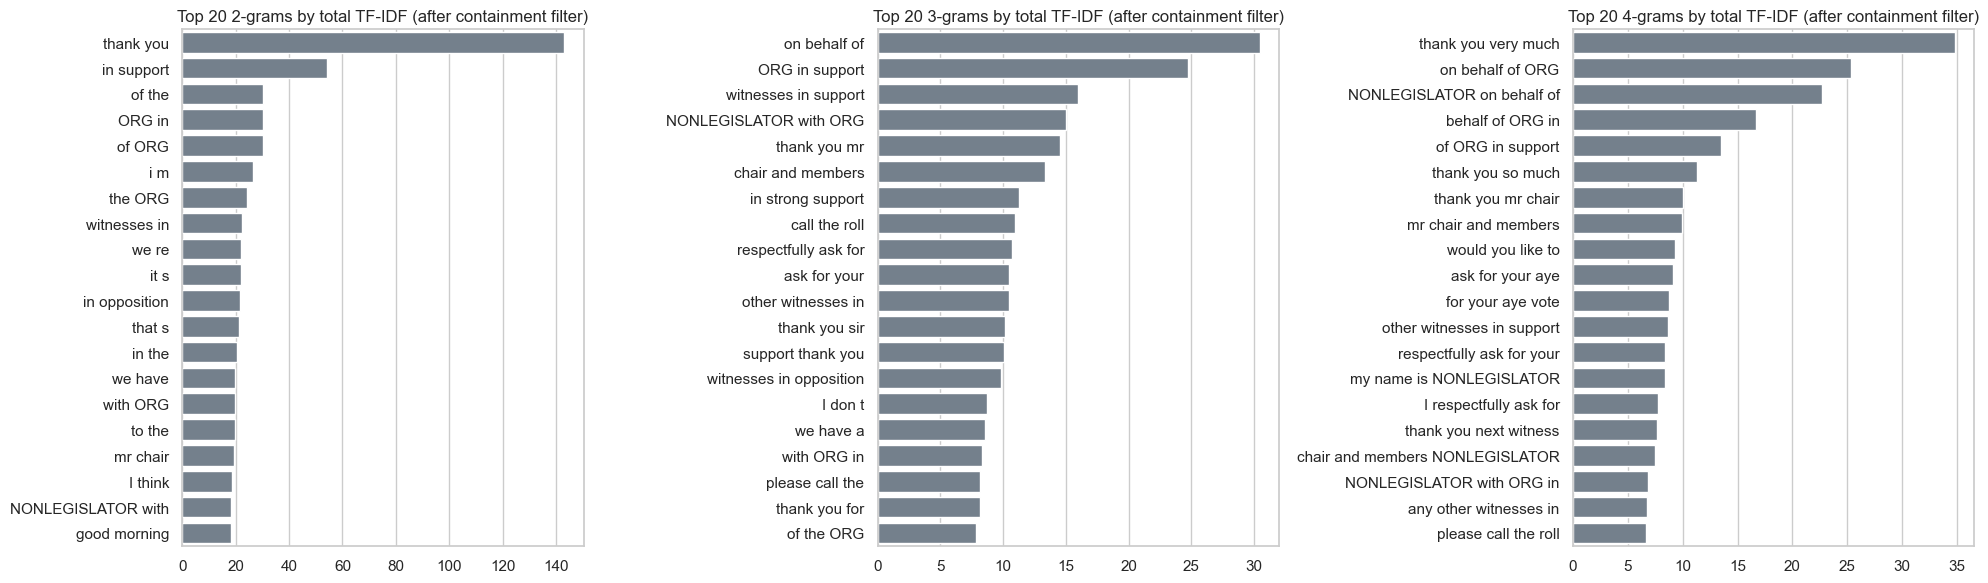

In [10]:
# Apply the filter. Keep unfiltered copies in case you want to compare.
X_all_raw, feat_all_raw, ngram_len_raw = X_all, feat_all, ngram_len

X_all = normalize(X_all_raw[:, keep_mask])     # re-normalise rows after dropping columns
feat_all = feat_all_raw[keep_mask]
ngram_len = ngram_len_raw[keep_mask]
print("Filtered matrix:", X_all.shape, "| docs with no remaining feature:", int((X_all.getnnz(axis=1) == 0).sum()))

# Top n-grams by order after filtering — compare with the pre-filter plots above
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
s_all = np.asarray(X_all.sum(axis=0)).ravel()
for ax, n in zip(axes, (2, 3, 4)):
    idx = np.where(ngram_len == n)[0]
    top = idx[np.argsort(-s_all[idx])[:20]]
    sns.barplot(x=s_all[top], y=feat_all[top], ax=ax, color="slategray")
    ax.set_title(f"Top 20 {n}-grams by total TF-IDF (after containment filter)"); ax.set_ylabel("")
plt.tight_layout(); plt.show()

## 3. Dimensionality reduction and clustering

TF-IDF spaces are far too sparse/high-dimensional for k-means or t-SNE directly, so we:
1. Reduce with **TruncatedSVD** (latent semantic analysis) to 100 components, then L2-normalise (spherical k-means behaviour).
2. Choose **k** for k-means by silhouette score on the SVD space.
3. Project to 2-D with **t-SNE** for visualisation only.

Explained variance ratio (first 100 comps): 0.256


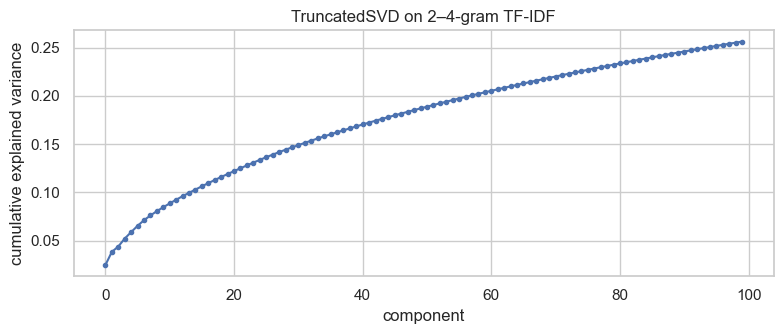

In [11]:
N_COMPONENTS = 100
svd = TruncatedSVD(n_components=N_COMPONENTS, random_state=RANDOM_STATE)
Z = svd.fit_transform(X_all)
Z = normalize(Z)
print(f"Explained variance ratio (first {N_COMPONENTS} comps): {svd.explained_variance_ratio_.sum():.3f}")

plt.figure(figsize=(8, 3.5))
plt.plot(np.cumsum(svd.explained_variance_ratio_), marker=".")
plt.xlabel("component"); plt.ylabel("cumulative explained variance"); plt.title("TruncatedSVD on 2–4-gram TF-IDF")
plt.tight_layout(); plt.show()

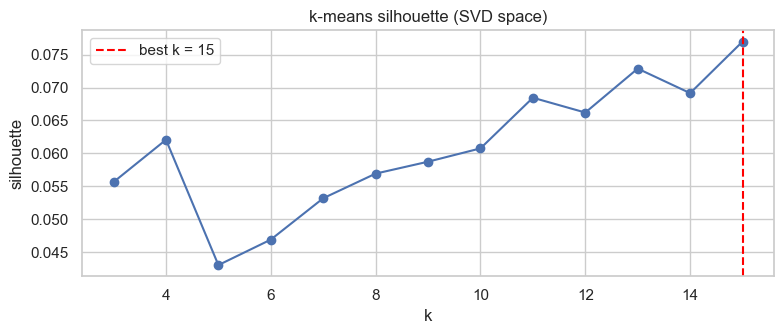

cluster,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14
size,128,62,285,89,67,85,146,113,538,365,126,143,259,76,136


In [12]:
ks = list(range(3, 16))
sil = []
for k in ks:
    km = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE).fit(Z)
    sil.append(silhouette_score(Z, km.labels_, sample_size=min(2000, len(Z)), random_state=RANDOM_STATE))

best_k = ks[int(np.argmax(sil))]
plt.figure(figsize=(8, 3.5))
plt.plot(ks, sil, marker="o"); plt.axvline(best_k, ls="--", c="red", label=f"best k = {best_k}")
plt.xlabel("k"); plt.ylabel("silhouette"); plt.title("k-means silhouette (SVD space)"); plt.legend()
plt.tight_layout(); plt.show()

kmeans = KMeans(n_clusters=best_k, n_init=20, random_state=RANDOM_STATE).fit(Z)
df["cluster"] = kmeans.labels_
df["cluster"].value_counts().sort_index().to_frame("size").T

In [13]:
tsne = TSNE(n_components=2, perplexity=35, init="pca", learning_rate="auto",
            metric="cosine", random_state=RANDOM_STATE)
emb = tsne.fit_transform(Z)
df["tsne_x"], df["tsne_y"] = emb[:, 0], emb[:, 1]

## 4. Cluster visualisations

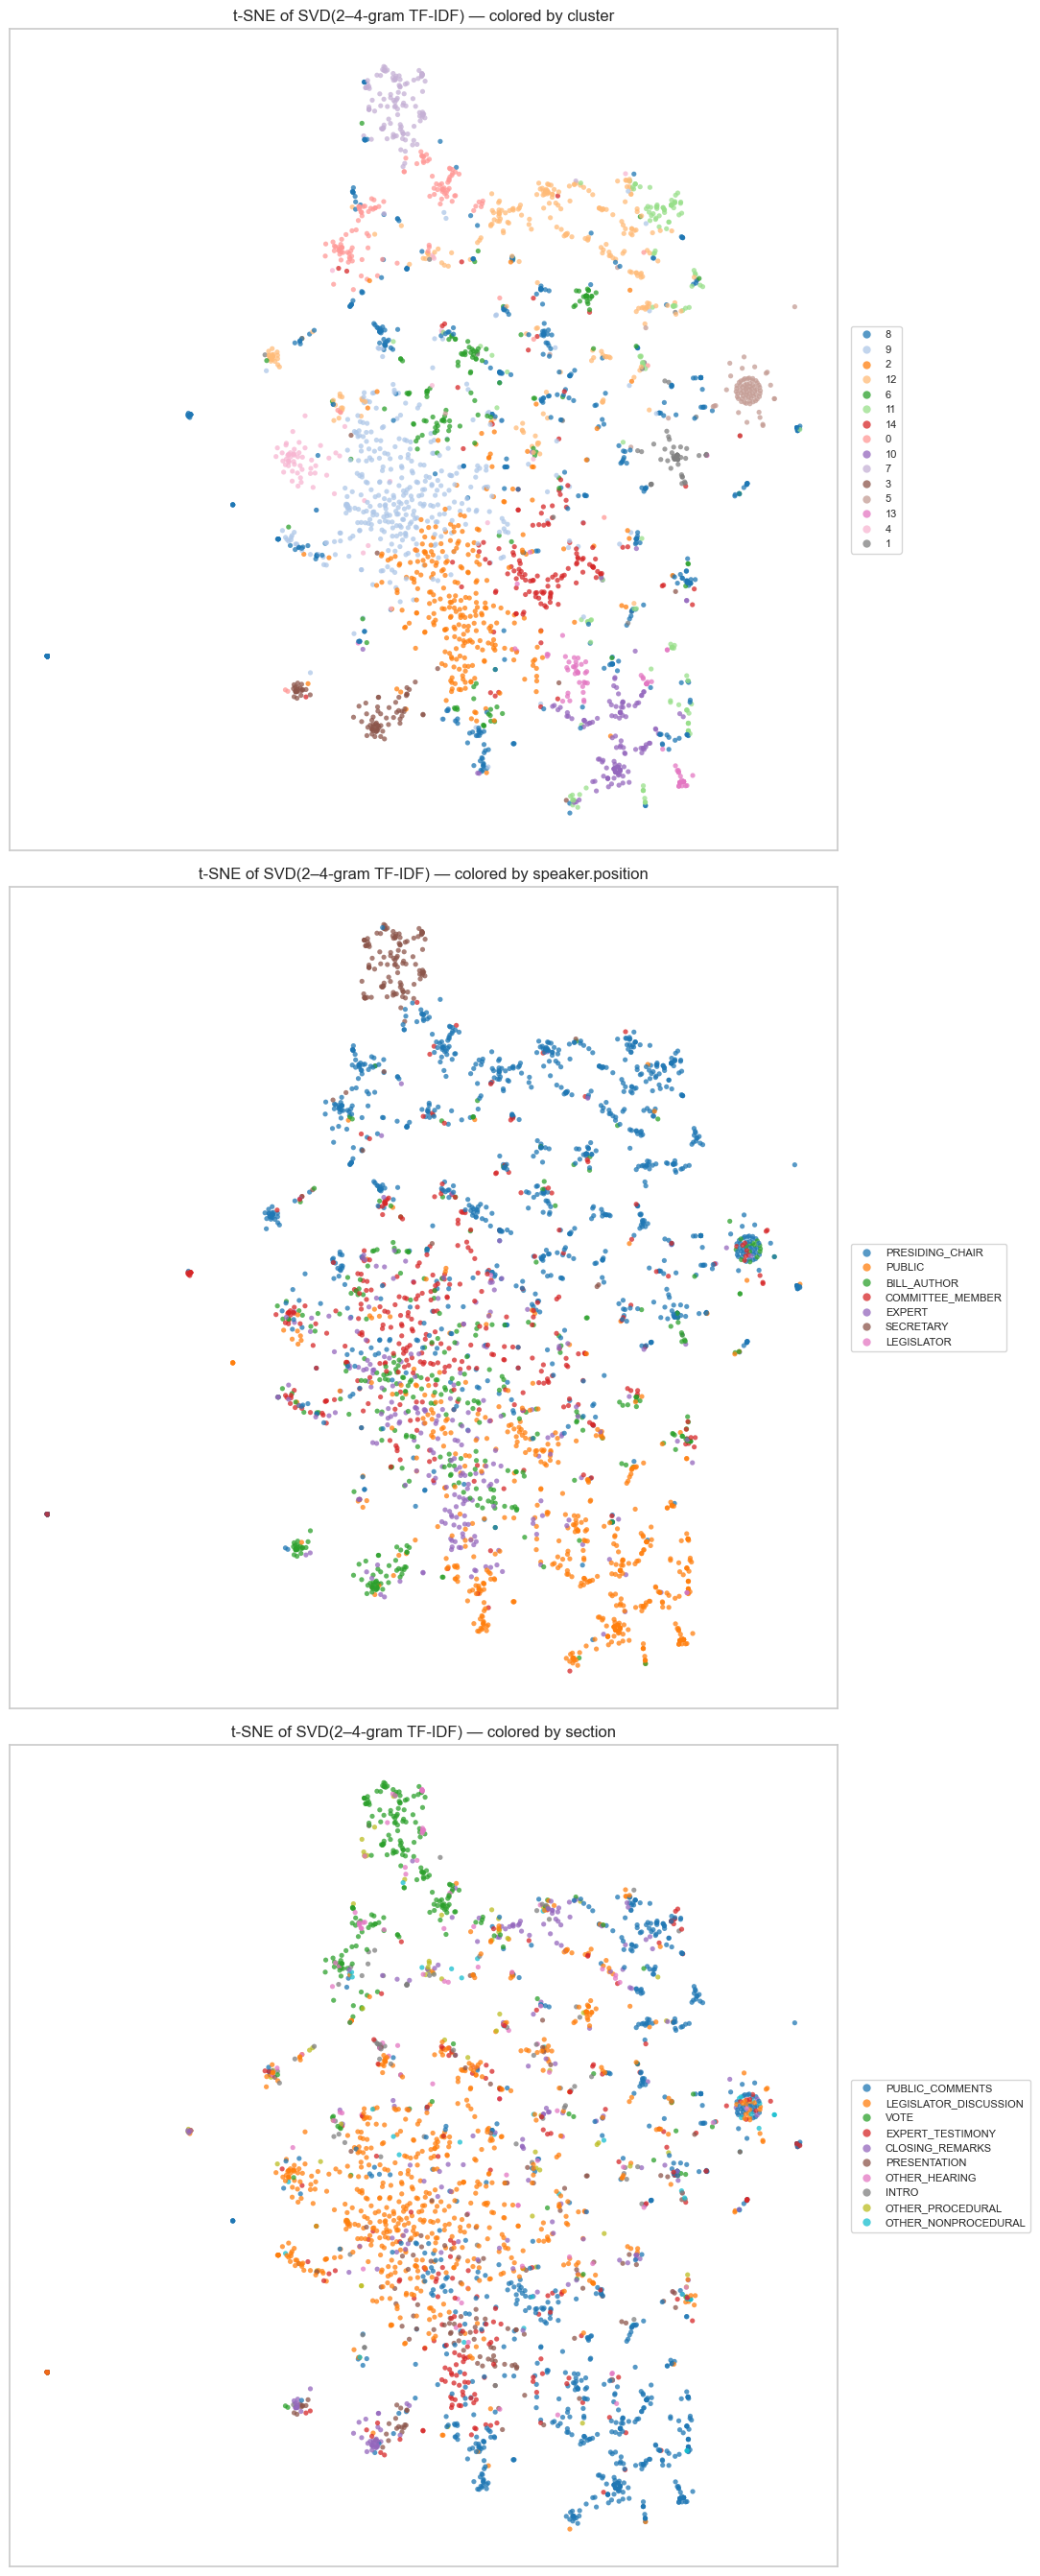

In [14]:
def scatter_by(col, ax, palette="tab10", legend_cols=1):
    order = df[col].value_counts().index.tolist()
    sns.scatterplot(data=df, x="tsne_x", y="tsne_y", hue=col, hue_order=order,
                    palette=palette, s=14, alpha=0.75, linewidth=0, ax=ax)
    ax.set_title(f"t-SNE of SVD(2–4-gram TF-IDF) — colored by {col}")
    ax.set_xlabel(""); ax.set_ylabel(""); ax.set_xticks([]); ax.set_yticks([])
    ax.legend(loc="center left", bbox_to_anchor=(1.01, 0.5), fontsize=8, ncol=legend_cols, markerscale=1.6)

fig, axes = plt.subplots(3, 1, figsize=(11, 27))
scatter_by("cluster", axes[0], palette="tab20")
scatter_by("speaker.position", axes[1])
scatter_by("section", axes[2])
plt.tight_layout(); plt.show()

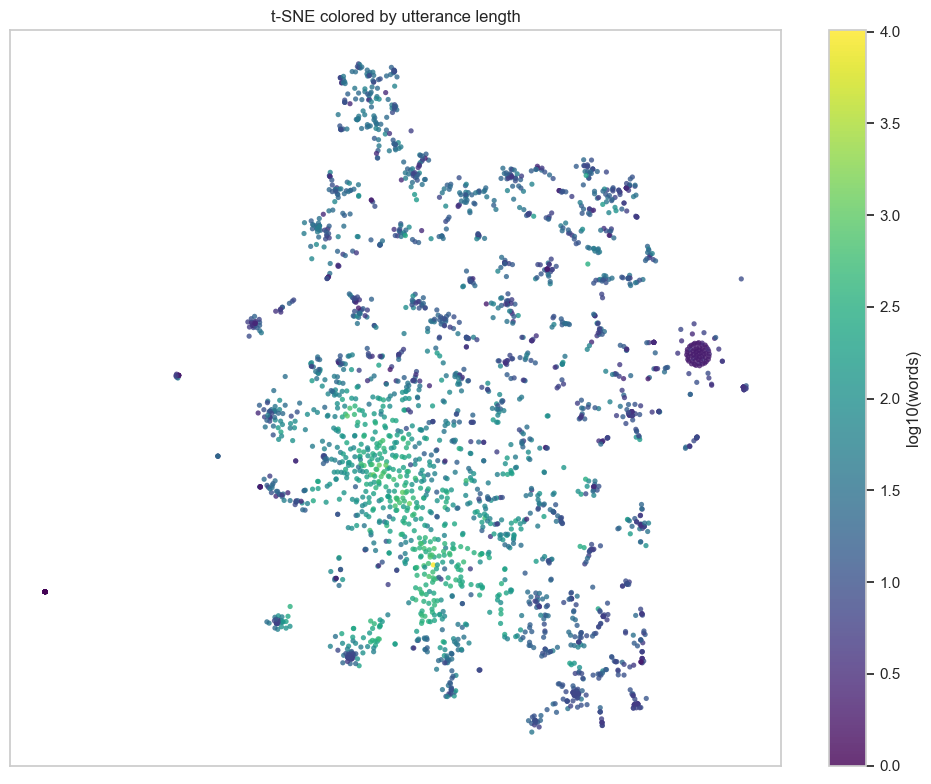

In [15]:
# Utterance length is a confounder worth checking on the map
fig, ax = plt.subplots(figsize=(10, 8))
sc = ax.scatter(df["tsne_x"], df["tsne_y"], c=np.log10(df["n_words"]), cmap="viridis", s=14, alpha=0.8, linewidths=0)
plt.colorbar(sc, label="log10(words)")
ax.set_title("t-SNE colored by utterance length"); ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()

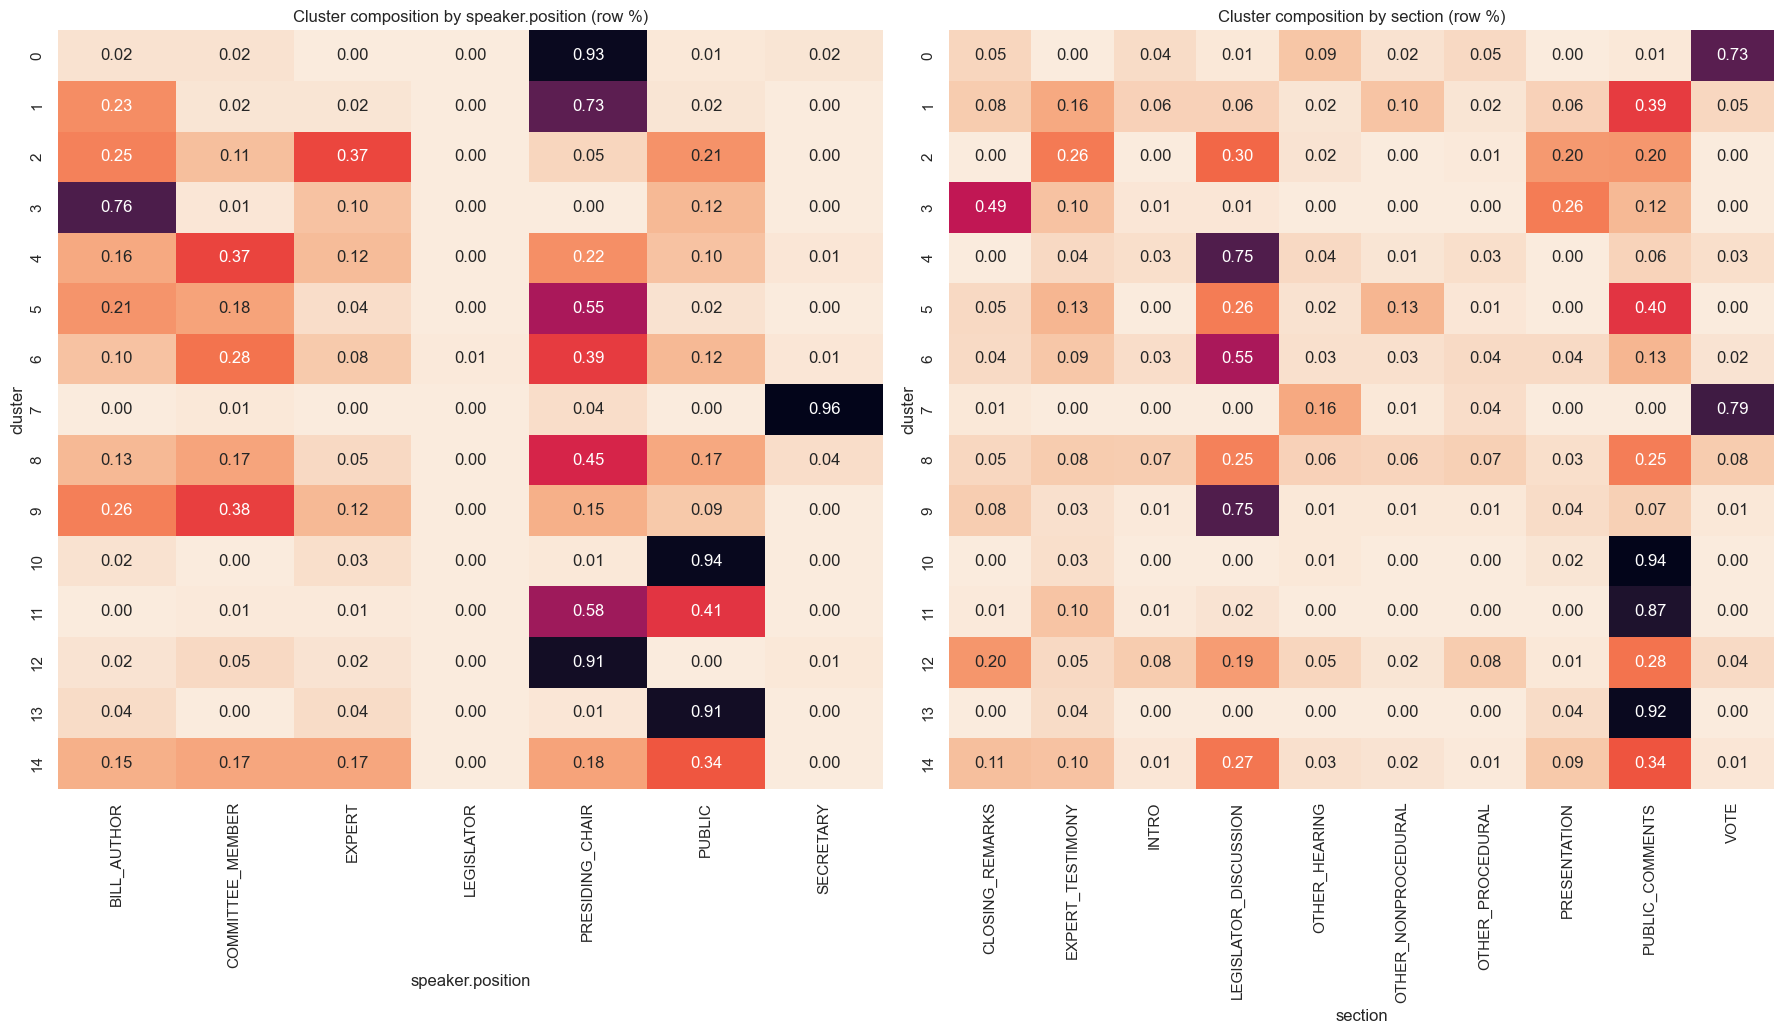

In [16]:
# How do clusters line up with the labels? Row-normalised composition heatmaps.
fig, axes = plt.subplots(1, 2, figsize=(18, 0.5 * best_k + 3))
for ax, col in zip(axes, ["speaker.position", "section"]):
    ct = pd.crosstab(df["cluster"], df[col], normalize="index")
    sns.heatmap(ct, annot=True, fmt=".2f", cmap="rocket_r", ax=ax, cbar=False)
    ax.set_title(f"Cluster composition by {col} (row %)")
plt.tight_layout(); plt.show()

In [17]:
# Characterise each cluster by the n-grams with the highest centroid weight in the original TF-IDF space
def cluster_top_ngrams(X, labels, feats, k=10):
    rows = []
    for c in np.unique(labels):
        cen = np.asarray(X[labels == c].mean(axis=0)).ravel()
        top = np.argsort(-cen)[:k]
        rows.append({"cluster": c, "size": int((labels == c).sum()),
                     "top_ngrams": ", ".join(feats[top])})
    return pd.DataFrame(rows)

cluster_terms = cluster_top_ngrams(X_all, df["cluster"].values, feat_all, k=10)
pd.set_option("display.max_colwidth", None)
cluster_terms

,cluster,size,top_ngrams
0,0,128,"the roll, call the, call the roll, please call the, please call the roll, we ll, thank you, the roll open, that bill, is out"
1,1,62,"thank you very much, thank you, you very much next, very much next witness, very much good morning, you very much mr, you very much good, next witness, very much mr chair, good morning"
2,2,285,"in the, of the, in GPE, the ORG, to the, on the, with the, the state, this is, it s"
3,3,89,"ask for, aye vote, respectfully ask for, ask for your, ask for your aye, for your, for your aye vote, respectfully ask for your, I respectfully ask for, an aye vote"
4,4,67,"don t, I don t, t have, don t have, I don t know, don t know, I don t have, I don t think, why not, don t see"
5,5,85,"thank you, thank you all, thank you thank you, you all, ms BILL_AUTHOR, mm hm, thank you additional, thank you NONLEGISLATOR, great thank you, thank you senator"
6,6,146,"mr COMMITTEE_MEMBER, i m, do you, do you have, you have, so i, a question, i m sorry, and i, i ll"
7,7,113,"COMMITTEE_MEMBER aye, PRESIDING_CHAIR aye, ORG aye, aye COMMITTEE_MEMBER aye, motion is, GPE aye, aye ORG, do pass, the motion, the motion is"
8,8,538,"thank you, senator COMMITTEE_MEMBER, thank you sir, move BILL, you re, thank you so much, thank you mr, thank you next witness, good morning, next witness"
9,9,365,"I think, it s, that s, we re, going to, that we, of the, and I, to be, in the"


## 5. N-grams most correlated with each class (one-vs-rest)

For every n-gram feature *x* and every class *c*, we compute the **Pearson correlation** between the TF-IDF column *x* and the binary indicator `1[label == c]` (a point-biserial correlation). A high positive value means the n-gram is heavily weighted in class *c* relative to all other classes. This is computed fully sparse so it scales to the whole vocabulary.

Classes with fewer than `MIN_CLASS_SIZE` utterances are skipped (correlations there are pure noise).

In [18]:
MIN_CLASS_SIZE = 10

def ngram_class_correlations(X, labels, feats):
    """Return DataFrame [features × classes] of Pearson r between each TF-IDF column and each one-vs-rest indicator."""
    X = sparse.csc_matrix(X, dtype=np.float64)
    n = X.shape[0]
    classes = [c for c, cnt in pd.Series(labels).value_counts().items() if cnt >= MIN_CLASS_SIZE]
    Y = np.column_stack([(labels == c).astype(np.float64) for c in classes])   # n × C

    mean_x = np.asarray(X.mean(axis=0)).ravel()
    mean_x2 = np.asarray(X.multiply(X).mean(axis=0)).ravel()
    sd_x = np.sqrt(np.maximum(mean_x2 - mean_x**2, 0))
    mean_y = Y.mean(axis=0)
    sd_y = np.sqrt(mean_y * (1 - mean_y))

    cov = (X.T @ Y) / n - np.outer(mean_x, mean_y)                            # V × C
    with np.errstate(divide="ignore", invalid="ignore"):
        r = cov / np.outer(sd_x, sd_y)
    r[~np.isfinite(r)] = 0.0
    return pd.DataFrame(r, index=feats, columns=classes)

def top_k_per_class(corr, k=10):
    frames = []
    for c in corr.columns:
        s = corr[c].nlargest(k)
        frames.append(pd.DataFrame({"class": c, "rank": range(1, k + 1), "ngram": s.index, "r": s.values}))
    return pd.concat(frames, ignore_index=True)

def plot_top_ngrams(top, title, ncols=3):
    classes = top["class"].unique()
    nrows = int(np.ceil(len(classes) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(6.5 * ncols, 3.6 * nrows), squeeze=False)
    for ax, c in zip(axes.ravel(), classes):
        sub = top[top["class"] == c]
        sns.barplot(data=sub, y="ngram", x="r", ax=ax, color="steelblue")
        ax.set_title(f"{c} (n={int((df[title]==c).sum())})", fontsize=11); ax.set_ylabel(""); ax.set_xlabel("Pearson r (one-vs-rest)")
        ax.tick_params(axis="y", labelsize=8.5)
    for ax in axes.ravel()[len(classes):]:
        ax.axis("off")
    fig.suptitle(f"Top-10 n-grams by correlation with {title}", fontsize=14, y=1.01)
    plt.tight_layout(); plt.show()

### 5a. `speaker.position`

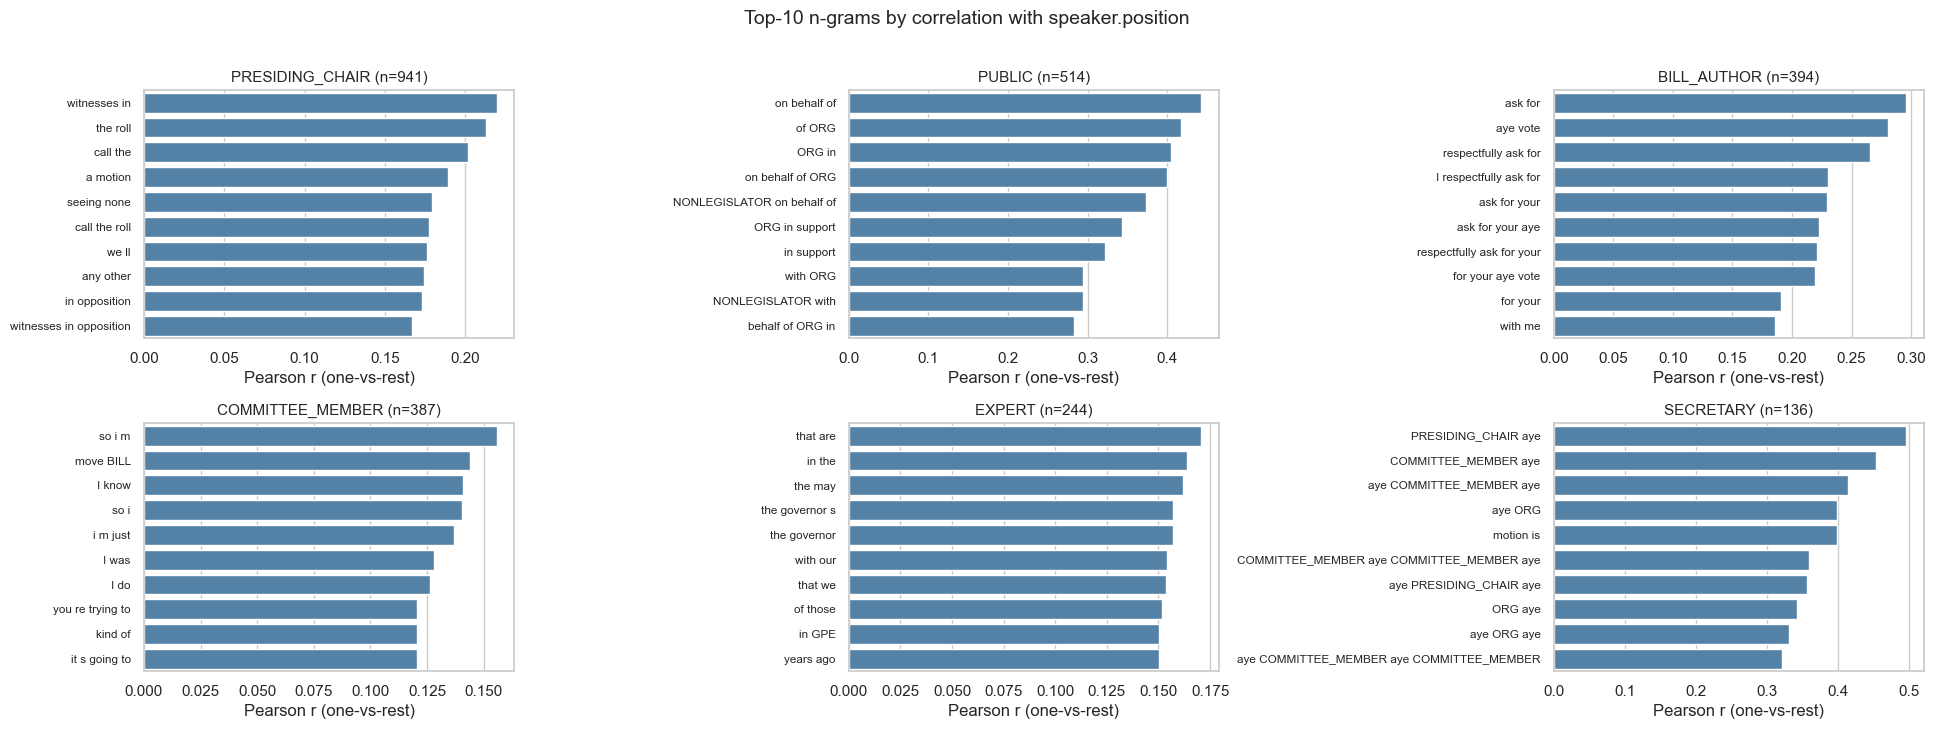

class,BILL_AUTHOR,COMMITTEE_MEMBER,EXPERT,PRESIDING_CHAIR,PUBLIC,SECRETARY
rank,,,,,,
1,ask for,so i m,that are,witnesses in,on behalf of,PRESIDING_CHAIR aye
2,aye vote,move BILL,in the,the roll,of ORG,COMMITTEE_MEMBER aye
3,respectfully ask for,I know,the may,call the,ORG in,aye COMMITTEE_MEMBER aye
4,I respectfully ask for,so i,the governor s,a motion,on behalf of ORG,aye ORG
5,ask for your,i m just,the governor,seeing none,NONLEGISLATOR on behalf of,motion is
6,ask for your aye,I was,with our,call the roll,ORG in support,COMMITTEE_MEMBER aye COMMITTEE_MEMBER aye
7,respectfully ask for your,I do,that we,we ll,in support,aye PRESIDING_CHAIR aye
8,for your aye vote,you re trying to,of those,any other,with ORG,ORG aye
9,for your,kind of,in GPE,in opposition,NONLEGISLATOR with,aye ORG aye


In [19]:
corr_speaker = ngram_class_correlations(X_all, df["speaker.position"].values, feat_all)
top_speaker = top_k_per_class(corr_speaker, k=10)
plot_top_ngrams(top_speaker, "speaker.position")
top_speaker.pivot(index="rank", columns="class", values="ngram")

### 5b. `section`

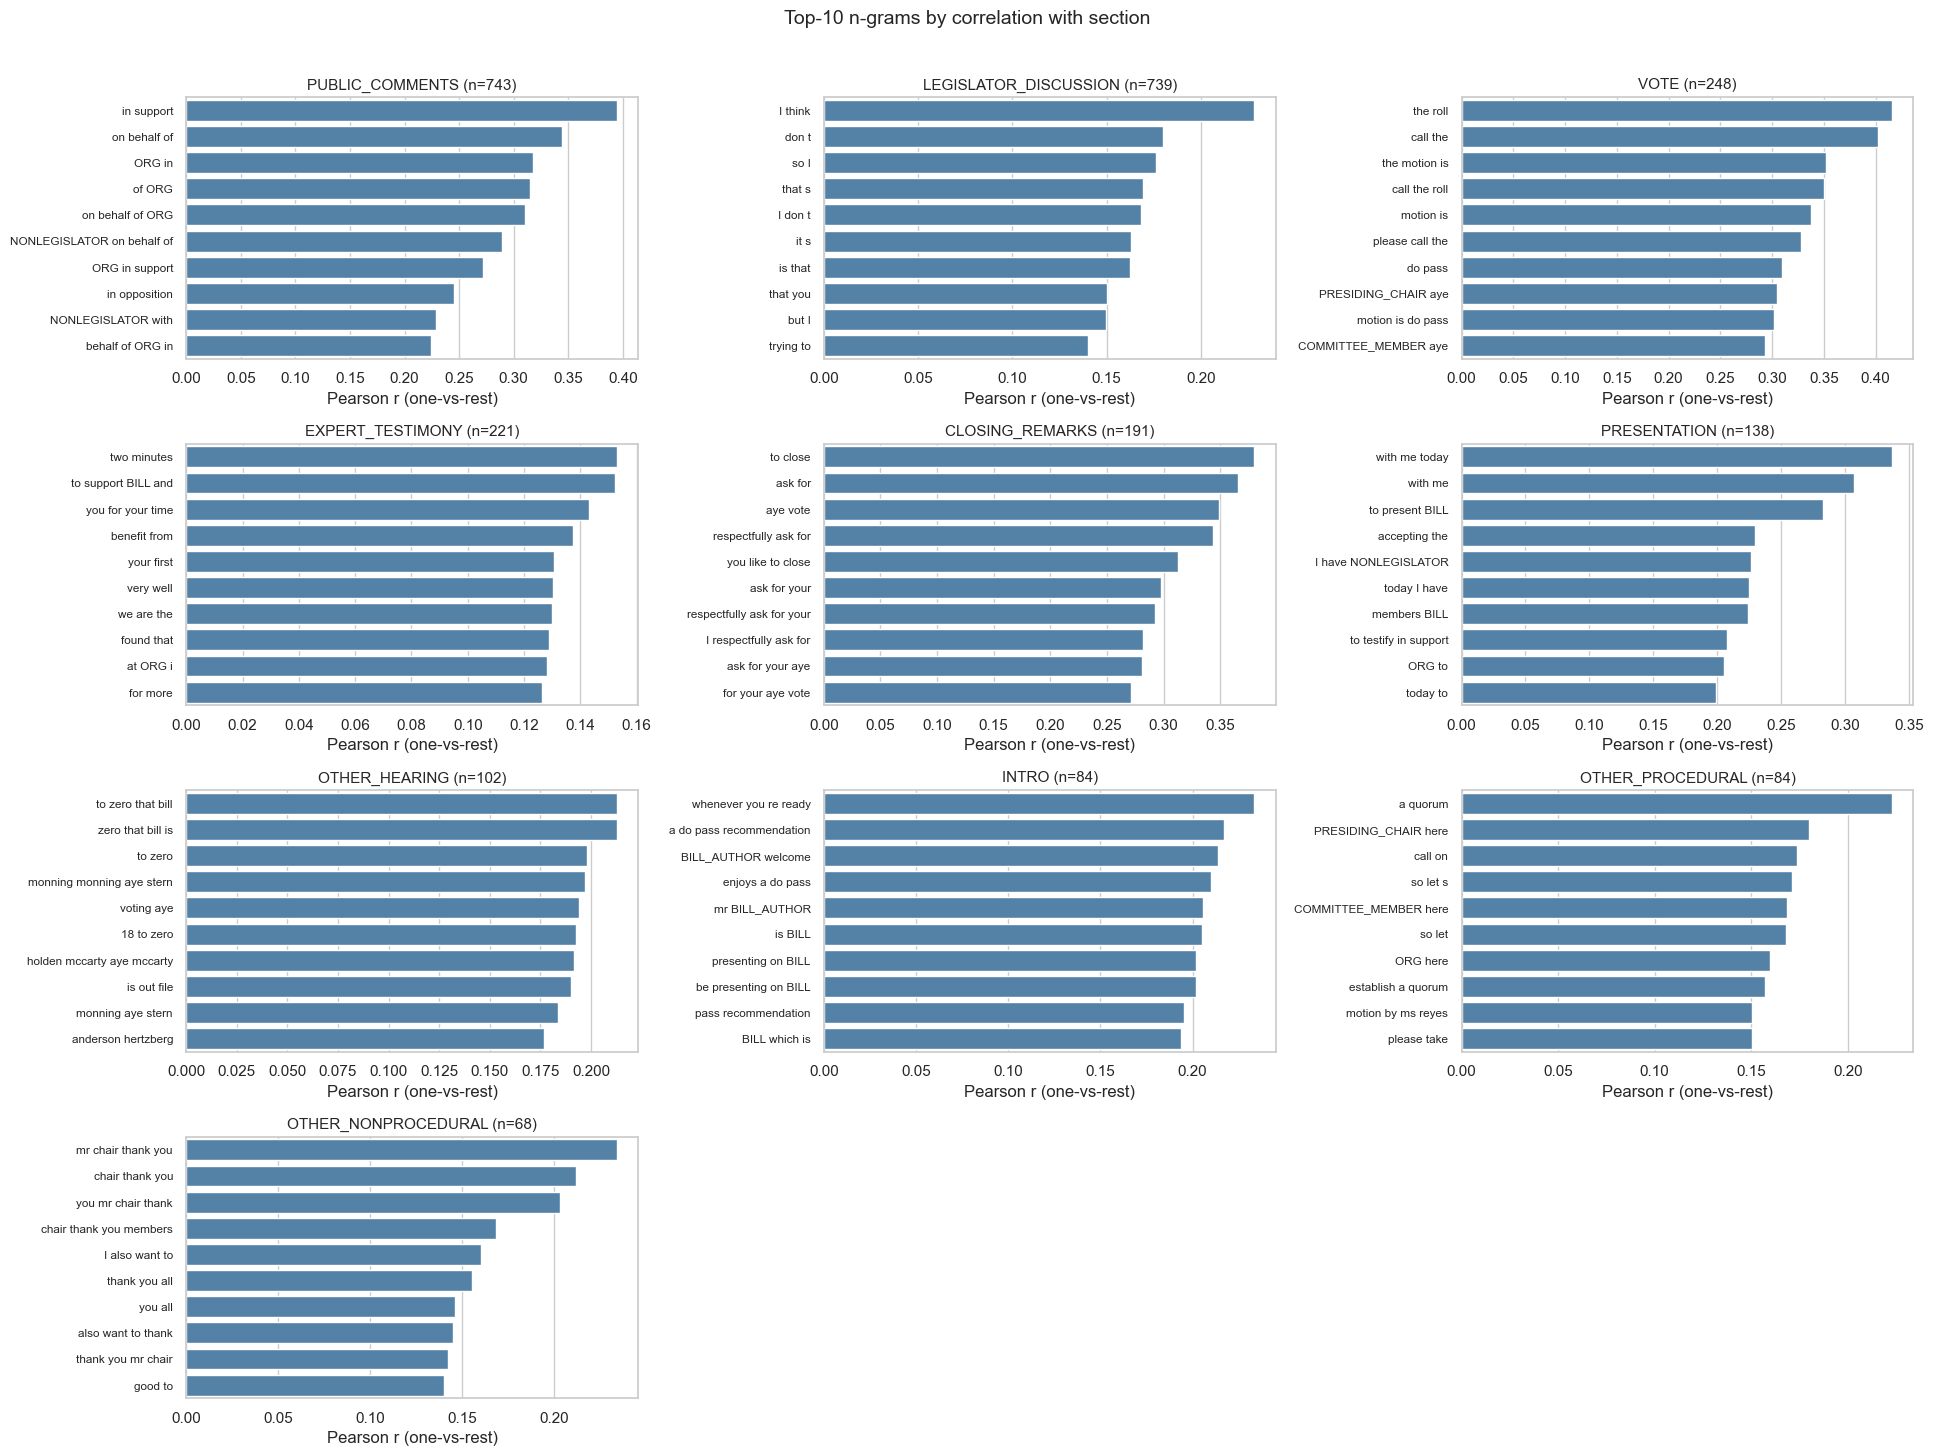

class,CLOSING_REMARKS,EXPERT_TESTIMONY,INTRO,LEGISLATOR_DISCUSSION,OTHER_HEARING,OTHER_NONPROCEDURAL,OTHER_PROCEDURAL,PRESENTATION,PUBLIC_COMMENTS,VOTE
rank,,,,,,,,,,
1,to close,two minutes,whenever you re ready,I think,to zero that bill,mr chair thank you,a quorum,with me today,in support,the roll
2,ask for,to support BILL and,a do pass recommendation,don t,zero that bill is,chair thank you,PRESIDING_CHAIR here,with me,on behalf of,call the
3,aye vote,you for your time,BILL_AUTHOR welcome,so I,to zero,you mr chair thank,call on,to present BILL,ORG in,the motion is
4,respectfully ask for,benefit from,enjoys a do pass,that s,monning monning aye stern,chair thank you members,so let s,accepting the,of ORG,call the roll
5,you like to close,your first,mr BILL_AUTHOR,I don t,voting aye,I also want to,COMMITTEE_MEMBER here,I have NONLEGISLATOR,on behalf of ORG,motion is
6,ask for your,very well,is BILL,it s,18 to zero,thank you all,so let,today I have,NONLEGISLATOR on behalf of,please call the
7,respectfully ask for your,we are the,presenting on BILL,is that,holden mccarty aye mccarty,you all,ORG here,members BILL,ORG in support,do pass
8,I respectfully ask for,found that,be presenting on BILL,that you,is out file,also want to thank,establish a quorum,to testify in support,in opposition,PRESIDING_CHAIR aye
9,ask for your aye,at ORG i,pass recommendation,but I,monning aye stern,thank you mr chair,motion by ms reyes,ORG to,NONLEGISLATOR with,motion is do pass


In [20]:
corr_section = ngram_class_correlations(X_all, df["section"].values, feat_all)
top_section = top_k_per_class(corr_section, k=10)
plot_top_ngrams(top_section, "section", ncols=3)
top_section.pivot(index="rank", columns="class", values="ngram")

### 5c. Breakdown by n-gram order

Are the most discriminative features mostly bigrams, or do longer phrases carry signal too? Below: for each class, the top-10 correlated features restricted to each order separately.

In [21]:
def top_by_order(corr, label_col, k=10):
    out = {}
    for n in (2, 3, 4):
        mask = ngram_len == n
        sub = corr.loc[mask]
        out[n] = pd.concat({c: sub[c].nlargest(k).reset_index()["index"] for c in sub.columns}, axis=1)
    return out

by_order_speaker = top_by_order(corr_speaker, "speaker.position")
for n, t in by_order_speaker.items():
    print(f"\n=== speaker.position — top-10 {n}-grams ===")
    display(t)


=== speaker.position — top-10 2-grams ===


,PRESIDING_CHAIR,PUBLIC,BILL_AUTHOR,COMMITTEE_MEMBER,EXPERT,SECRETARY
0,witnesses in,of ORG,ask for,move BILL,that are,PRESIDING_CHAIR aye
1,the roll,ORG in,aye vote,I know,in the,COMMITTEE_MEMBER aye
2,call the,in support,for your,so i,the may,aye ORG
3,a motion,with ORG,with me,I was,the governor,motion is
4,seeing none,NONLEGISLATOR with,for an,I do,with our,ORG aye
5,we ll,of GPE,members BILL,kind of,that we,aye GPE
6,any other,ORG we,mr chair,going to,of those,GPE aye
7,in opposition,support BILL,accepting the,i ve,in GPE,pass to
8,thank you,ORG also,based on,but I,years ago,aye stern
9,would you,GPE in,our state,about the,of our,aye lackey



=== speaker.position — top-10 3-grams ===


,PRESIDING_CHAIR,PUBLIC,BILL_AUTHOR,COMMITTEE_MEMBER,EXPERT,SECRETARY
0,call the roll,on behalf of,respectfully ask for,so i m,the governor s,aye COMMITTEE_MEMBER aye
1,witnesses in opposition,ORG in support,ask for your,i m just,the may revision,aye PRESIDING_CHAIR aye
2,witnesses in support,NONLEGISLATOR with ORG,an aye vote,I don t,we have had,aye ORG aye
3,have a motion,in strong support,with me today,i m not,with ORG to,the motion is
4,other witnesses in,NONLEGISLATOR i m,to present BILL,I do think,we are the,motion is due
5,please call the,support thank you,I have NONLEGISLATOR,not going to,at ORG i,aye GPE aye
6,we have a,with ORG in,today I have,how do you,a very very,to ORG PRESIDING_CHAIR
7,questions or comments,BILL thank you,I ask for,going to be,and we know,monning aye stern
8,thank you any,chair and members,chair thank you,s going to,a situation where,do pass to
9,are there any,members NONLEGISLATOR with,madam chair and,don t know,of the work,gonzalez fletcher aye



=== speaker.position — top-10 4-grams ===


,PRESIDING_CHAIR,PUBLIC,BILL_AUTHOR,COMMITTEE_MEMBER,EXPERT,SECRETARY
0,would you like to,on behalf of ORG,I respectfully ask for,you re trying to,to support BILL and,COMMITTEE_MEMBER aye COMMITTEE_MEMBER aye
1,any other witnesses in,NONLEGISLATOR on behalf of,ask for your aye,it s going to,you for your time,aye COMMITTEE_MEMBER aye COMMITTEE_MEMBER
2,we have a motion,behalf of ORG in,respectfully ask for your,what you re trying,the work that we,motion is do pass
3,please call the roll,of ORG in support,for your aye vote,I don t know,urge an aye vote,PRESIDING_CHAIR aye PRESIDING_CHAIR aye
4,other witnesses in support,chair and members NONLEGISLATOR,ask for an aye,to thank you for,your support thank you,motion is due pass
5,you like to close,my name is NONLEGISLATOR,for an aye vote,not going to be,members my name is,mccarty aye mccarty aye
6,thank you very much,members NONLEGISLATOR on behalf,thank you mr chair,I just want to,my name is NONLEGISLATOR,bloom aye bloom aye
7,any witnesses in opposition,NONLEGISLATOR with ORG in,chair and members BILL,so i m not,NONLEGISLATOR and i m,to ORG PRESIDING_CHAIR aye
8,wishing to speak in,ORG in strong support,respectfully ask for an,i m trying to,so this is a,aye monning monning aye
9,a motion and a,name is NONLEGISLATOR i,thank you madam chair,so i m just,as it relates to,monning monning aye stern


In [22]:
by_order_section = top_by_order(corr_section, "section")
for n, t in by_order_section.items():
    print(f"\n=== section — top-10 {n}-grams ===")
    display(t)


=== section — top-10 2-grams ===


,PUBLIC_COMMENTS,LEGISLATOR_DISCUSSION,VOTE,EXPERT_TESTIMONY,CLOSING_REMARKS,PRESENTATION,OTHER_HEARING,INTRO,OTHER_PROCEDURAL,OTHER_NONPROCEDURAL
0,in support,I think,the roll,two minutes,to close,with me,to zero,BILL_AUTHOR welcome,a quorum,you all
1,ORG in,don t,call the,benefit from,ask for,accepting the,voting aye,mr BILL_AUTHOR,PRESIDING_CHAIR here,good to
2,of ORG,so I,motion is,your first,aye vote,members BILL,anderson hertzberg,is BILL,call on,thank you
3,in opposition,that s,do pass,very well,for your,ORG to,mccarty aye,pass recommendation,COMMITTEE_MEMBER here,ll get
4,NONLEGISLATOR with,it s,PRESIDING_CHAIR aye,found that,would you,today to,count is,you re,so let,appreciate it
5,with ORG,is that,COMMITTEE_MEMBER aye,for more,like to,BILL requires,is file,here so,ORG here,mr chair
6,witnesses in,that you,the motion,several years,for an,to ensure,is two,your patience,please take,our witnesses
7,of GPE,but I,pass to,40 of,a motion,known as,vote count,BILL which,like they,much appreciate
8,ORG also,trying to,aye ORG,impacted by,chair s,and NONLEGISLATOR,two to,on BILL,we need,coming back
9,of BILL,re not,aye GPE,she had,ORG seeing,NONLEGISLATOR a,aye stern,BILL_AUTHOR BILL,establish a,like me



=== section — top-10 3-grams ===


,PUBLIC_COMMENTS,LEGISLATOR_DISCUSSION,VOTE,EXPERT_TESTIMONY,CLOSING_REMARKS,PRESENTATION,OTHER_HEARING,INTRO,OTHER_PROCEDURAL,OTHER_NONPROCEDURAL
0,on behalf of,I don t,the motion is,we are the,respectfully ask for,with me today,18 to zero,presenting on BILL,so let s,chair thank you
1,ORG in support,and I think,call the roll,at ORG i,ask for your,to present BILL,is out file,BILL which is,establish a quorum,thank you all
2,NONLEGISLATOR with ORG,I think that,please call the,it will be,you may close,I have NONLEGISLATOR,monning aye stern,item 4 BILL,now have a,we ll get
3,other witnesses in,so that s,aye PRESIDING_CHAIR aye,sponsors of BILL,an aye vote,today I have,six to zero,on to BILL,take the roll,to have you
4,in strong support,so I think,aye COMMITTEE_MEMBER aye,leadership on this,comments seeing none,by accepting the,chair voting aye,this is BILL,have a quorum,so when we
5,support thank you,I think the,do pass to,we have had,have a motion,with me to,to zero the,like to proceed,lift the call,also want to
6,with ORG in,a lot of,the roll open,of BILL and,from ORG seeing,be available to,ORG or ORG,for your patience,and seconded by,they re also
7,NONLEGISLATOR i m,s going to,aye ORG aye,members I am,we have a,accepting the amendments,is two to,which is ORG,we now have,today thank you
8,witnesses in opposition,not going to,to ORG PRESIDING_CHAIR,opportunity to share,I ask for,to ensure that,is file item,if we could,so we have,welcome to ORG
9,BILL thank you,we re not,aye GPE aye,of ORG bill,just ask for,BILL will allow,any public comment,as soon as,we need a,that s one



=== section — top-10 4-grams ===


,PUBLIC_COMMENTS,LEGISLATOR_DISCUSSION,VOTE,EXPERT_TESTIMONY,CLOSING_REMARKS,PRESENTATION,OTHER_HEARING,INTRO,OTHER_PROCEDURAL,OTHER_NONPROCEDURAL
0,on behalf of ORG,I don t think,motion is do pass,to support BILL and,you like to close,to testify in support,to zero that bill,whenever you re ready,motion by ms reyes,mr chair thank you
1,NONLEGISLATOR on behalf of,it s going to,the motion is do,you for your time,respectfully ask for your,with me today to,zero that bill is,a do pass recommendation,a motion by ms,you mr chair thank
2,behalf of ORG in,and I think that,please call the roll,so much for your,I respectfully ask for,to present BILL which,monning monning aye stern,enjoys a do pass,let s establish a,chair thank you members
3,of ORG in support,not going to be,COMMITTEE_MEMBER aye COMMITTEE_MEMBER aye,urge an aye vote,ask for your aye,today I have NONLEGISLATOR,holden mccarty aye mccarty,be presenting on BILL,s establish a quorum,I also want to
4,chair and members NONLEGISLATOR,I don t know,is do pass to,your support thank you,for your aye vote,chair and members BILL,aye stern stern aye,file item 4 BILL,it s a good,also want to thank
5,my name is NONLEGISLATOR,I think it s,PRESIDING_CHAIR aye PRESIDING_CHAIR aye,NONLEGISLATOR and i m,would you like to,I have NONLEGISLATOR with,monning aye stern stern,BILL it enjoys a,gonzalez fletcher kiley COMMITTEE_MEMBER,thank you mr chair
6,other witnesses in support,you re trying to,do pass to ORG,this is a very,ask for an aye,me today I have,ORG aye monning monning,it enjoys a do,we have a motion,have a lot of
7,any other witnesses in,we re talking about,aye COMMITTEE_MEMBER aye COMMITTEE_MEMBER,is NONLEGISLATOR and i,for an aye vote,with me today I,amended to appropriations the,to move on to,items on the agenda,you mr chair members
8,members NONLEGISLATOR on behalf,that s going to,please call the absent,so this is a,respectfully ask for an,here to present BILL,appropriations holden mccarty aye,you re ready sir,that s what I,very much mr chair
9,NONLEGISLATOR with ORG in,I just want to,the motion is due,thank you for allowing,recommending an aye vote,m here to present,aye mccarty aye mullin,the floor is yours,GPE ORG and ORG,all right we re


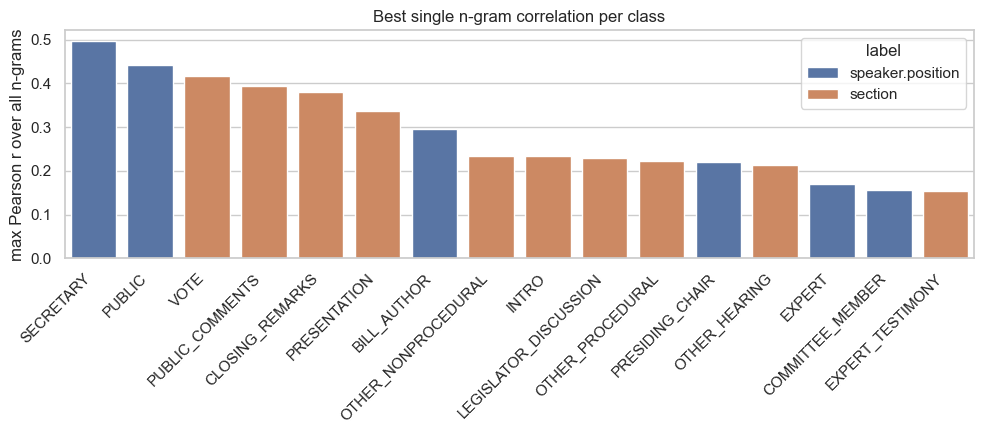

In [23]:
# Strength of the single best feature per class — how separable is each class in n-gram space?
best = pd.concat({
    "speaker.position": corr_speaker.max(axis=0),
    "section": corr_section.max(axis=0),
}, names=["label", "class"]).reset_index(name="max_r")
plt.figure(figsize=(10, 4.5))
sns.barplot(data=best.sort_values("max_r", ascending=False), x="class", y="max_r", hue="label", dodge=False)
plt.xticks(rotation=45, ha="right"); plt.ylabel("max Pearson r over all n-grams"); plt.xlabel("")
plt.title("Best single n-gram correlation per class"); plt.tight_layout(); plt.show()

## 6. Takeaways / next steps

- Check the cluster composition heatmaps: clusters that are near-pure in `section` (e.g. VOTE / roll-call style language) will show up as tight islands in the t-SNE map, while discussion-heavy sections will overlap.
- `speaker.position` is harder to separate from surface n-grams than `section` — compare the "best single n-gram correlation" bars.
- Utterance length is a strong latent factor; consider stratifying by length or using `max_features`/`min_df` tuning if length dominates the embedding.
- Natural extensions: chi² / mutual-information feature selection, a linear classifier with coefficient inspection, or UMAP instead of t-SNE for a more global-structure-preserving map.